In [1]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
!kaggle datasets download -d mathchi/online-retail-ii-data-set-from-ml-repository

Dataset URL: https://www.kaggle.com/datasets/mathchi/online-retail-ii-data-set-from-ml-repository
License(s): DbCL-1.0
 85% 49.0M/57.5M [00:00<00:00, 86.4MB/s]
100% 57.5M/57.5M [00:00<00:00, 86.0MB/s]


In [7]:
! unzip "online-retail-ii-data-set-from-ml-repository.zip"

Archive:  online-retail-ii-data-set-from-ml-repository.zip
  inflating: Year 2009-2010.csv      
  inflating: Year 2010-2011.csv      
  inflating: online_retail_II.xlsx   


In [11]:
import pandas as pd

In [36]:
df=pd.read_csv("Year_2010-2011.csv", encoding='latin-1')

In [37]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Exercise 1: Specific Customer Segmentation Based on RFM Analysis Background

Objective: Use Gemini to customize an RFM (Recency, Frequency, Monetary) analysis for customer segmentation.

RFM (Recency, Frequency, Monetary) analysis is a method to evaluate customers based on their purchasing behavior. It assesses how recently a customer purchased (Recency), how often they buy (Frequency), and how much they spend (Monetary). This helps in categorizing customers for targeted marketing and understanding customer value.

In [39]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [40]:
df.dropna(inplace=True)

based on my df create a new RFM table

In [42]:
# Step 1: Prepare the data
# Drop rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])

# Ensure InvoiceDateFormated is in datetime format
df['InvoiceDateFormated'] = pd.to_datetime(df['InvoiceDate'])

# Step 2: Calculate Recency
# Assume 'current_date' as the latest date in the data for the sake of calculation
current_date = df['InvoiceDateFormated'].max()
recency_df = df.groupby('Customer ID').agg({'InvoiceDateFormated': lambda x: (current_date - x.max()).days})
recency_df.rename(columns={'InvoiceDateFormated': 'Recency'}, inplace=True)

# Step 3: Calculate Frequency
frequency_df = df.groupby('Customer ID').agg({'Invoice': 'nunique'})
frequency_df.rename(columns={'Invoice': 'Frequency'}, inplace=True)

# Step 4: Calculate Monetary
df['TotalPrice'] = df['Quantity'] * df['Price']
monetary_df = df.groupby('Customer ID').agg({'TotalPrice': 'sum'})
monetary_df.rename(columns={'TotalPrice': 'Monetary'}, inplace=True)

# Step 5: Combine RFM Scores
rfm_df = recency_df.merge(frequency_df, on='Customer ID').merge(monetary_df, on='Customer ID')

# Rank the customers based on RFM values (optional)
rfm_df['R_rank'] = rfm_df['Recency'].rank(method='first')
rfm_df['F_rank'] = rfm_df['Frequency'].rank(method='first', ascending=False)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(method='first', ascending=False)

# Normalize the ranks into quantiles (optional)
rfm_df['R_rank'] = pd.qcut(rfm_df['R_rank'], 4, labels=[4, 3, 2, 1])
rfm_df['F_rank'] = pd.qcut(rfm_df['F_rank'], 4, labels=[1, 2, 3, 4])
rfm_df['M_rank'] = pd.qcut(rfm_df['M_rank'], 4, labels=[1, 2, 3, 4])

# Calculate RFM Score
rfm_df['RFM_Score'] = rfm_df[['R_rank', 'F_rank', 'M_rank']].sum(axis=1)

print(rfm_df.head())

             Recency  Frequency  Monetary R_rank F_rank M_rank  RFM_Score
Customer ID                                                              
12346.0          325          2      0.00      1      3      4          8
12347.0            1          7   4310.00      4      1      1          6
12348.0           74          4   1797.24      2      2      1          5
12349.0           18          1   1757.55      3      3      1          7
12350.0          309          1    334.40      1      3      3          7


Explanation:
* Recency: Calculated as the number of days since the customer's last purchase.
* Frequency: The number of unique transactions the customer has made.
* Monetary: The total amount spent by the customer.

This script will produce a DataFrame with Recency, Frequency, Monetary, and an overall RFM_Score. Higher RFM scores typically indicate better customers.

# Exercise 2: Anonymizing Personal Data in Retail Transactions with Gemini

Objective: Apply Gemini to anonymize personal customer data in the dataset.

In [43]:
# prompt: anonymize personal customer data in the dataset.

# Replace with hashed values for anonymization
import hashlib

def hash_data(data):
  return hashlib.sha256(data.encode()).hexdigest()

df['HashedCountry'] = df['Country'].apply(hash_data)

print(df.head())


  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  Price  Customer ID         Country InvoiceDateFormated  \
0  12/1/2010 8:26   2.55      17850.0  United Kingdom 2010-12-01 08:26:00   
1  12/1/2010 8:26   3.39      17850.0  United Kingdom 2010-12-01 08:26:00   
2  12/1/2010 8:26   2.75      17850.0  United Kingdom 2010-12-01 08:26:00   
3  12/1/2010 8:26   3.39      17850.0  United Kingdom 2010-12-01 08:26:00   
4  12/1/2010 8:26   3.39      17850.0  United Kingdom 2010-12-01 08:26:00   

   TotalPrice                                      HashedCountry  
0       15.30  8d23a6e37e0a6431a8f1b43a91026dcff5

# Exercise 3: Gemini-Assisted Querying for Time Series Sales Analysis

Objective: Use Gemini to assist in querying and analyzing sales trends in the dataset.

In [44]:
# prompt: Calculate the total revenue and total quantity sold for each month. Create a new column for total sales (‘TotalPrice’) by multiplying ‘Quantity’ by ‘Price’.

# Calculate total sales
df['TotalPrice'] = df['Quantity'] * df['Price']

# Extract month and year from the InvoiceDate
df['YearMonth'] = df['InvoiceDateFormated'].dt.to_period('M')

# Calculate total revenue and quantity sold for each month
monthly_sales = df.groupby('YearMonth').agg({'TotalPrice': 'sum', 'Quantity': 'sum'})

print(monthly_sales)


            TotalPrice  Quantity
YearMonth                       
2010-12     554604.020    296362
2011-01     475074.380    269379
2011-02     436546.150    262833
2011-03     579964.610    344012
2011-04     426047.851    278585
2011-05     648251.080    367852
2011-06     608013.160    356922
2011-07     574238.481    363418
2011-08     616368.000    386612
2011-09     931440.372    537496
2011-10     974603.590    569666
2011-11    1132407.740    669915
2011-12     342524.380    203837


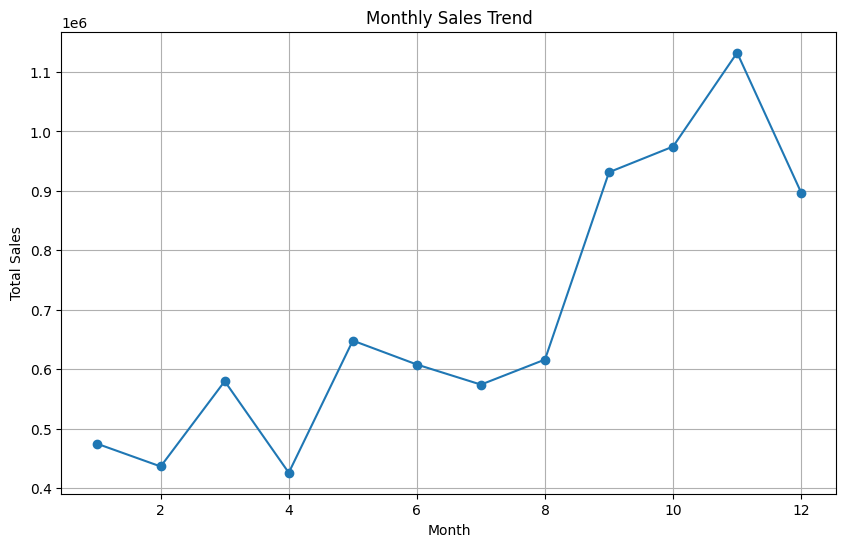

Quarter
1    21.278873
2    21.044158
3    22.107879
4    18.681880
Name: TotalPrice, dtype: float64


In [45]:
# prompt: analyze monthly sales trends and seasonality using ‘InvoiceDate’, ‘Quantity’, and ‘Price’.

# Calculate total sales per month
df['TotalPrice'] = df['Quantity'] * df['Price']
df['Month'] = df['InvoiceDateFormated'].dt.month

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

# Plot monthly sales trends
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.grid(True)
plt.show()

# Analyze seasonality
# Example: Calculate average sales for each quarter
df['Quarter'] = df['InvoiceDateFormated'].dt.quarter
quarterly_sales = df.groupby('Quarter')['TotalPrice'].mean()
print(quarterly_sales)

# Further analysis could include:
# - Comparing sales across different years
# - Identifying specific products with seasonal trends
# - Statistical tests for seasonality


Top 10 selling products:
 Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

Top spending customers:
 Customer ID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
Name: TotalPrice, dtype: float64


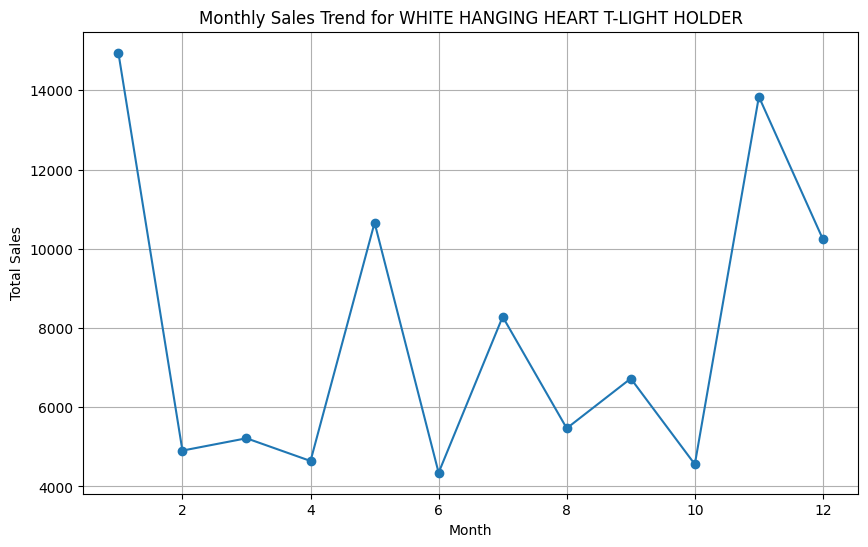


Sales by country:
 Country
United Kingdom          6767873.394
Netherlands              284661.540
EIRE                     250285.220
Germany                  221698.210
France                   196730.840
Australia                137077.270
Switzerland               55739.400
Spain                     54774.580
Belgium                   40910.960
Sweden                    36595.910
Japan                     35340.620
Norway                    35163.460
Portugal                  29059.810
Finland                   22326.740
Channel Islands           20086.290
Denmark                   18768.140
Italy                     16890.510
Cyprus                    12946.290
Austria                   10154.320
Singapore                  9120.390
Poland                     7213.140
Israel                     6994.250
Greece                     4710.520
Iceland                    4310.000
Canada                     3666.380
Unspecified                2667.070
Malta                      2505.470


In [46]:
# prompt: process these queries and provide insights into sales trends

import matplotlib.pyplot as plt
# Example queries and insights

# 1. Top selling products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 selling products:\n", top_products)
# Insight: Identify popular products for potential promotions or inventory management.

# 2. Customer spending behavior
customer_spending = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
print("\nTop spending customers:\n", customer_spending.head())
# Insight: Segment customers based on spending for targeted marketing.

# 3. Sales trend for a specific product
product_sales = df[df['Description'] == 'WHITE HANGING HEART T-LIGHT HOLDER'].groupby('Month')['TotalPrice'].sum()
plt.figure(figsize=(10, 6))
product_sales.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend for WHITE HANGING HEART T-LIGHT HOLDER')
plt.grid(True)
plt.show()
# Insight: Analyze sales patterns for specific products to optimize stock levels.

# 4. Sales by country
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print("\nSales by country:\n", country_sales)
# Insight: Identify key markets and potential areas for expansion.

# 5. Impact of discounts (if discount information is available)
# Assuming a 'Discount' column exists (add logic to calculate discounts if not available)
# discounted_sales = df[df['Discount'] > 0].groupby('Month')['TotalPrice'].sum()
# ... (further analysis and visualization)
# Insight: Evaluate the effectiveness of discount strategies.


Forecast for next month using SMA: 1001379.91
Forecast for next month using Exponential Smoothing: 941716.9380983424


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


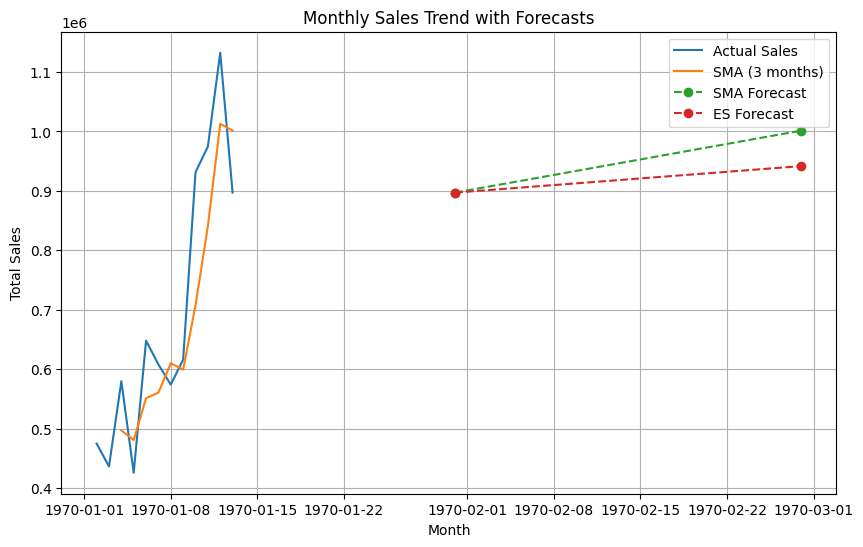

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming monthly_sales is a Series with TotalPrice as values
monthly_sales = pd.DataFrame(monthly_sales, columns=['TotalPrice']) # Convert Series to DataFrame

# Simple Moving Average (SMA) for forecasting
# Calculate 3-month moving average
monthly_sales['SMA_3'] = monthly_sales['TotalPrice'].rolling(window=3).mean()

# Forecast for the next month (assuming the data ends in December)
forecast_sma = monthly_sales['SMA_3'].iloc[-1]
print("Forecast for next month using SMA:", forecast_sma)

# Exponential Smoothing for forecasting
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit the model
model = SimpleExpSmoothing(monthly_sales['TotalPrice'])
fit = model.fit()

# Forecast for the next month
forecast_es = fit.forecast(1)
print("Forecast for next month using Exponential Smoothing:", forecast_es.iloc[0]) # Access the first element using iloc[0]

# Plot actual sales and forecasts
plt.figure(figsize=(10, 6))
monthly_sales['TotalPrice'].plot(label='Actual Sales')
monthly_sales['SMA_3'].plot(label='SMA (3 months)')
plt.plot(pd.date_range(start=monthly_sales.index[-1], periods=2, freq='M'),
         [monthly_sales['TotalPrice'].iloc[-1], forecast_sma],
         label='SMA Forecast', linestyle='--', marker='o')
plt.plot(pd.date_range(start=monthly_sales.index[-1], periods=2, freq='M'),
         [monthly_sales['TotalPrice'].iloc[-1], forecast_es.iloc[0]], # Access the first element using iloc[0]
         label='ES Forecast', linestyle='--', marker='o')

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend with Forecasts')
plt.legend()
plt.grid(True)
plt.show()

Forecast for next quarter using SMA: 2285791.2815


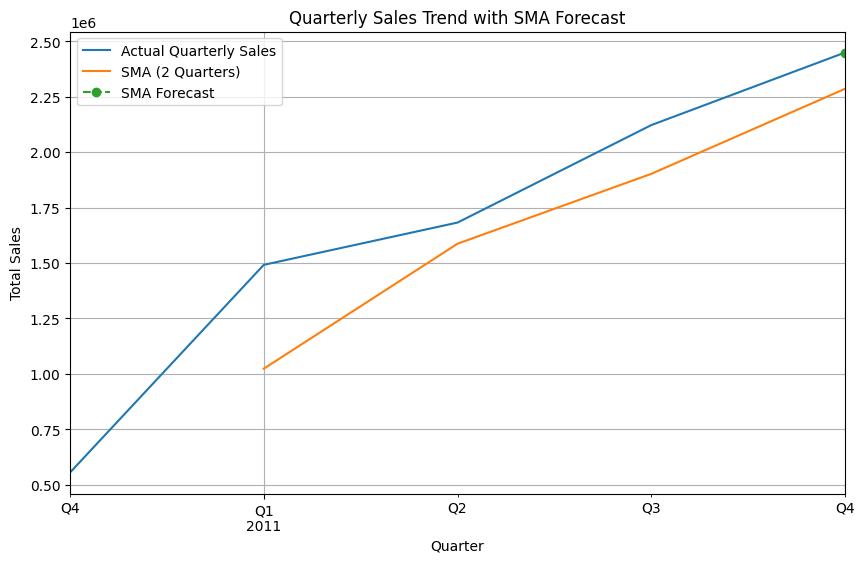

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
# Calculate quarterly sales
df['Quarter'] = df['InvoiceDateFormated'].dt.to_period('Q')
quarterly_sales = df.groupby('Quarter')['TotalPrice'].sum()

# Convert Series to DataFrame
quarterly_sales = pd.DataFrame(quarterly_sales, columns=['TotalPrice'])

# Simple Moving Average (SMA) for quarterly sales forecast
# Calculate 2-quarter moving average
quarterly_sales['SMA_2'] = quarterly_sales['TotalPrice'].rolling(window=2).mean()

# Forecast for the next quarter
forecast_sma_quarter = quarterly_sales['SMA_2'].iloc[-1]
print("Forecast for next quarter using SMA:", forecast_sma_quarter)

# Plot actual quarterly sales and forecast
plt.figure(figsize=(10, 6))
quarterly_sales['TotalPrice'].plot(label='Actual Quarterly Sales')
quarterly_sales['SMA_2'].plot(label='SMA (2 Quarters)')

# Create a PeriodIndex for plotting the forecast
forecast_index = pd.period_range(start=quarterly_sales.index[-1], periods=2, freq='Q')
plt.plot(forecast_index,
         [quarterly_sales['TotalPrice'].iloc[-1], forecast_sma_quarter],
         label='SMA Forecast', linestyle='--', marker='o')

plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.title('Quarterly Sales Trend with SMA Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Discussion:
# SMA provides a basic forecast by averaging sales data from the last few periods (quarters in this case).
# It's simple to implement and understand but has limitations:
# - Assumes a constant trend and doesn't account for seasonality or cyclical patterns.
# - Lags behind trends, especially during periods of rapid change.
# - Sensitive to outliers.
# - Limited predictive power for longer-term forecasts.